# Phần 1. NumPy trong workflow ML/DL

Các bài dưới đây dùng dữ liệu nhỏ để mô phỏng preprocessing, inference và xử lý
tensor trong một pipeline thực tế.

In [1]:
STUDENT_NAME = "Huynh Nguyen Huy Hoang"  # TODO: Họ và tên
STUDENT_ID = "2550056"    # TODO: MSSV

print(f"Student: {STUDENT_NAME} ({STUDENT_ID})")

Student: Huynh Nguyen Huy Hoang (2550056)


In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 4.8)

DATA_CANDIDATES = [
    Path("week02/numpy-pandas-eda-hw/data/automobile_raw.csv"),
    Path("data/automobile_raw.csv"),
    Path("../data/automobile_raw.csv"),
]
DATA_PATH = next((path for path in DATA_CANDIDATES if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Không tìm thấy data/automobile_raw.csv")

print("Data path:", DATA_PATH.resolve())

Data path: /Users/huyhoang/mliot-pyml-2026-hw/week02/numpy-pandas-eda-hw/data/automobile_raw.csv


## N1. Stable softmax cho batch logits

Một classifier trả về `logits` có shape `(batch_size, num_classes)`. Tính softmax
theo từng mẫu bằng cách trừ giá trị lớn nhất trên mỗi hàng trước khi gọi `np.exp`.
Cách viết này tránh overflow khi logits có giá trị lớn.

**Biến đầu ra bắt buộc**

- `shifted_logits`: logits sau khi trừ row-wise maximum.
- `class_probabilities`: xác suất mỗi class, mỗi hàng có tổng bằng 1.
- `predicted_classes`: class có xác suất lớn nhất của từng mẫu.
- `confidence_scores`: xác suất lớn nhất của từng mẫu.

In [3]:
logits = np.array([
    [2.0, 1.0, 0.1],
    [1000.0, 1001.0, 999.0],
    [-2.0, -1.0, 3.0],
    [0.5, 0.5, 0.5],
], dtype=np.float64)

In [4]:
# TODO N1
shifted_logits = logits - np.max(logits,axis = 1).reshape(4,1)
exp_logits = np.exp(shifted_logits)

class_probabilities = exp_logits / np.sum(exp_logits,axis = 1,keepdims=True)
predicted_classes = np.argmax(class_probabilities,axis = 1)
confidence_scores = np.max(class_probabilities,axis = 1)

In [5]:
required = [
    "shifted_logits",
    "class_probabilities",
    "predicted_classes",
    "confidence_scores",
]
if not all(name in globals() for name in required):
    print("Complete N1 to run this self-check.")
else:
    assert class_probabilities.shape == logits.shape
    assert np.all(np.isfinite(class_probabilities))
    assert np.allclose(class_probabilities.sum(axis=1), 1.0)
    assert predicted_classes.shape == (logits.shape[0],)
    assert confidence_scores.shape == (logits.shape[0],)
    print("N1 self-check passed")

N1 self-check passed


## N2. Chuẩn hóa train và validation không gây leakage

Mỗi hàng là một mẫu, mỗi cột là một feature. Tính mean/std **chỉ từ `X_train`**,
sau đó dùng cùng thống kê để transform cả train và validation.

**Biến đầu ra bắt buộc**

- `train_feature_mean`, `train_feature_std`: shape `(4,)`.
- `X_train_scaled`: train set đã chuẩn hóa.
- `X_val_scaled`: validation set dùng thống kê từ train.

In [6]:
# Features: height_cm, weight_kg, activity_hours, age
X_train = np.array([
    [170.0, 65.0, 1.2, 22.0],
    [180.0, 80.0, 2.4, 35.0],
    [160.0, 50.0, 0.8, 19.0],
    [175.0, 70.0, 1.5, 28.0],
    [168.0, 60.0, 1.0, 24.0],
    [182.0, 90.0, 3.0, 41.0],
])

X_val = np.array([
    [172.0, 68.0, 1.4, 26.0],
    [190.0, 95.0, 3.4, 45.0],
])

In [7]:
# TODO N2
train_feature_mean = np.mean(X_train,axis = 0)
train_feature_std = np.std(X_train,axis=0)
X_train_scaled = (X_train - train_feature_mean)/train_feature_std
X_val_scaled = (X_val - train_feature_mean)/train_feature_std

In [8]:
required = [
    "train_feature_mean",
    "train_feature_std",
    "X_train_scaled",
    "X_val_scaled",
]
if not all(name in globals() for name in required):
    print("Complete N2 to run this self-check.")
else:
    assert X_train_scaled.shape == X_train.shape
    assert X_val_scaled.shape == X_val.shape
    assert np.allclose(X_train_scaled.mean(axis=0), 0.0)
    assert np.allclose(X_train_scaled.std(axis=0), 1.0)
    print("N2 self-check passed")

N2 self-check passed


## N3. Tạo review queue sau inference

Giả sử `class_probabilities` đến từ N1. Một prediction cần được kiểm tra thủ công
nếu dự đoán sai **hoặc** confidence nhỏ hơn `0.70`.

**Biến đầu ra bắt buộc**

- `correct_mask`
- `high_confidence_mask`
- `review_mask`
- `review_indices`

In [9]:
true_labels = np.array([0, 2, 2, 1])
confidence_threshold = 0.70

In [10]:
# TODO N3
correct_mask = (true_labels == predicted_classes)
# print(correct_mask)
high_confidence_mask = (confidence_scores >= confidence_threshold)
# print(high_confidence_mask)
review_mask = (~correct_mask | ~high_confidence_mask)
# print(review_mask)
review_indices = np.where(review_mask)[0]
# print(review_indices)

## N4. Tiền xử lý và augment một batch ảnh

`image_batch_uint8` có layout `(B, H, W, C)`. Chuyển batch về `float32` trong đoạn
`[0, 1]`, sau đó tạo một batch mới được flip ngang. Batch augment phải có bộ nhớ
độc lập để việc chỉnh sửa không làm thay đổi batch đã normalize.

Sau khi tạo batch augment, đặt pixel `augmented_batch[0, 0, 0, 0] = 1.0`.

**Biến đầu ra bắt buộc:** `normalized_batch`, `augmented_batch`.

In [11]:
image_batch_uint8 = (
    np.arange(2 * 4 * 4 * 3, dtype=np.uint8)
    .reshape(2, 4, 4, 3)
)

In [12]:
# TODO N4
normalized_batch = image_batch_uint8/255
augmented_batch = normalized_batch[:,:,::-1,:].copy()
augmented_batch[0, 0, 0, 0] = 1.0

# Phần 2. EDA với Automobile

Đọc `data/data_dictionary.md` trước khi xử lý.

## Câu hỏi mở đầu

1. Mỗi dòng đại diện cho đối tượng gì?
2. Ký hiệu missing value trong CSV là gì?
3. `symboling` có ý nghĩa gì?

**Trả lời**

<!-- Viết câu trả lời tại đây. -->

1. Mỗi dòng đại diện cho một mẫu xe trong bộ 1985 Auto Imports.
2. Giá trị thiếu (missing value) trong `automobile_raw.csv` được giữ dưới dạng ký hiệu `?`.
3. `symboling` có ý nghĩa là mức đánh giá rủi ro bảo hiểm từ -3 đến 3

## D1. Load và inspect raw CSV

Load dữ liệu sao cho dấu `?` vẫn là chuỗi để quan sát ảnh hưởng tới dtype.

**Biến đầu ra bắt buộc**

- `raw_df`: DataFrame raw.
- `raw_shape`: tuple.
- `raw_missing_marker_count`: tổng số dấu `?`.

In [13]:
# TODO D1
raw_df = pd.read_csv(DATA_PATH)
raw_shape = raw_df.shape
raw_missing_marker_count = (raw_df == '?').sum().sum()

## D2. Missing values và dtype

1. Thay `?` bằng `np.nan`.
2. Chuyển các cột trong `NUMERIC_COLUMNS` bằng `pd.to_numeric`.
3. Tạo báo cáo missing.

**Biến đầu ra bắt buộc:** `df_clean`, `missing_by_column`.

In [14]:
NUMERIC_COLUMNS = ['symboling', 'normalized_losses', 'wheel_base', 'length', 'width', 'height', 'curb_weight', 'engine_size', 'bore', 'stroke', 'compression_ratio', 'horsepower', 'peak_rpm', 'city_mpg', 'highway_mpg', 'price']

In [15]:
# TODO D2
df_clean = raw_df.replace('?',np.nan)
# print(df_clean[df_clean['price'].isna()])
# print(df_clean)
for column in NUMERIC_COLUMNS:
    df_clean[column] = pd.to_numeric(df_clean[column])
missing_by_column = df_clean.isna().sum()
# missing_by_column


### Giải thích cách làm sạch dữ liệu

- Vì sao không nên fill tất cả numeric columns bằng cùng một giá trị?
- Với `price`, lựa chọn drop hay fill phù hợp hơn cho bài EDA này? Vì sao?
- `normalized_losses` thiếu nhiều dữ liệu hơn các cột khác. Điều này ảnh hưởng thế nào?

**Nhận xét**

<!-- Viết 3--6 câu tại đây. -->

- Không nên fill tất cả numeric columns bằng cùng một giá trị vì từng column biểu diễn một feature khác nhau về giá trị, hệ quy chiếu, vì vậy không thể lấy thang đo chung để áp vào toàn bộ numeric columns
- Với `price`, nhìn chung thì data này khá đầy đủ, tuy nhiên biến động của price lại quá lớn nên mình có thể lựa chọn `drop` những giá trị NaN đó vì nếu `drop` thì không có ảnh hưởng nhiều nhưng nếu `fill` có thể làm sai lệch dữ liệu.
- Việc thiếu nhiều `normalized_losses` có thể khiến cho việc ước lượng mean và median của nó trở nên thiếu tin cậy

## D3. DataFrame sang NumPy

Dùng sáu cột trong `AUTO_FEATURES`. Drop các dòng thiếu ít nhất một trong
sáu cột, sau đó chuyển sang `float64` NumPy array và chuẩn hóa theo feature.

**Biến đầu ra bắt buộc**

- `analysis_df`
- `X_auto`
- `auto_feature_mean`
- `auto_feature_std`
- `X_auto_scaled`

In [16]:
AUTO_FEATURES = ['curb_weight', 'engine_size', 'horsepower', 'city_mpg', 'highway_mpg', 'price']

In [17]:
# TODO D3
analysis_df = df_clean.dropna(subset=AUTO_FEATURES)
X_auto = analysis_df[AUTO_FEATURES].to_numpy(dtype=np.float64)
auto_feature_mean = np.mean(X_auto,axis = 0)
auto_feature_std = np.std(X_auto,axis = 0)
X_auto_scaled = (X_auto - auto_feature_mean)/auto_feature_std

## D4. Outlier theo price z-score

Tính z-score của `price` bằng NumPy. Một dòng được xem là outlier trong bài
này khi `abs(z) > 2`.

**Biến đầu ra bắt buộc:** `price_z`, `price_outlier_mask`, `price_outliers`.

In [18]:
# TODO D4
price_index = df_clean["price"].to_numpy()
# print(price_index)
price_z = (price_index - np.mean(price_index))/np.std(price_index)
price_outlier_mask = (abs(price_z)>2)
# print(price_outlier_mask)
price_outliers = price_index[price_outlier_mask]
# print(price_outliers)

## D5. Correlation và GroupBy

**Biến đầu ra bắt buộc**

- `engine_price_corr`: Pearson correlation tính bằng NumPy.
- `price_by_body_style`: Series mean price theo `body_style`, sort index.

In [19]:
# TODO D5
df_clean.dropna(subset = ["price"], inplace=True)
engine_price_corr = np.corrcoef(df_clean["engine_size"], df_clean["price"])[0,1]
price_by_body_style = df_clean.groupby("body_style")["price"].mean().sort_index()

# Phần 3. Visualization và insight

Mỗi biểu đồ cần:

1. một câu hỏi;
2. title, axis labels và unit;
3. lựa chọn chart phù hợp;
4. 1--2 câu nhận xét ngay dưới chart.

## M2.1 Price phân phối như thế nào?

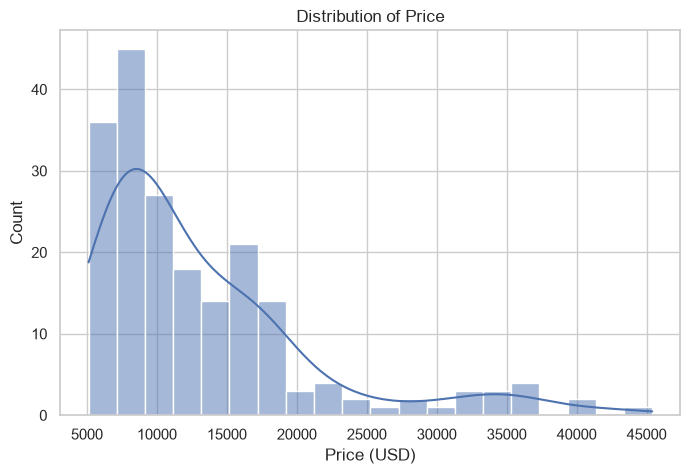

In [20]:
# TODO M2.1: histogram/KDE của price
plt.figure(figsize=(8,5))
sns.histplot(df_clean["price"], bins=20, kde=True)

plt.title("Distribution of Price")
plt.xlabel("Price (USD)")
plt.ylabel("Count")
plt.show()

**Nhận xét:** <!-- 1--2 câu -->

Nhận xét : Price được phân phối lệch phải, khi các giá trị của các xe được phân phối chủ yếu ở phân khúc rẻ (5000-20000 USD), và có một số dòng xe ở phân khúc giá cao ( > 20000 USD)

## M2.2 Dataset có cân bằng theo body style không?

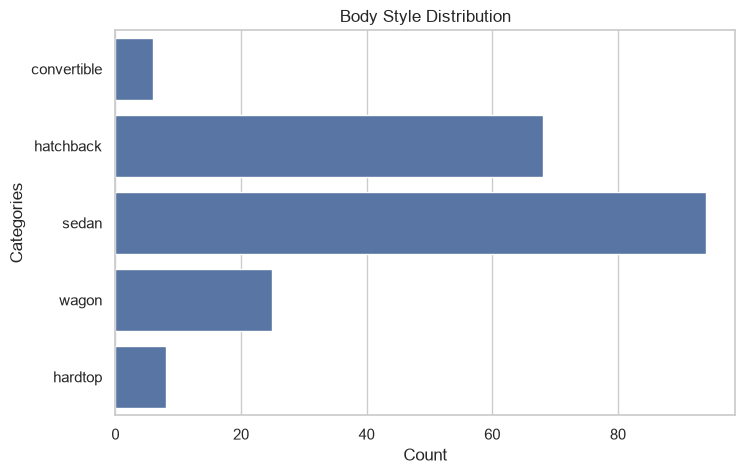

In [21]:
# TODO M2.2: countplot của body_style
plt.figure(figsize=(8,5))
sns.countplot(df_clean["body_style"])

plt.title("Body Style Distribution")
plt.xlabel("Count")
plt.ylabel("Categories")
plt.show()

**Nhận xét:** <!-- 1--2 câu -->

Nhận xét : Body Style đang không cân bằng đều, thực tế đang lệch nghiêm trọng khi sedan, hatchback chiếm tỉ lệ lớn và những style còn lại thì quá ít.

## M2.3 Price khác nhau theo body style ra sao?

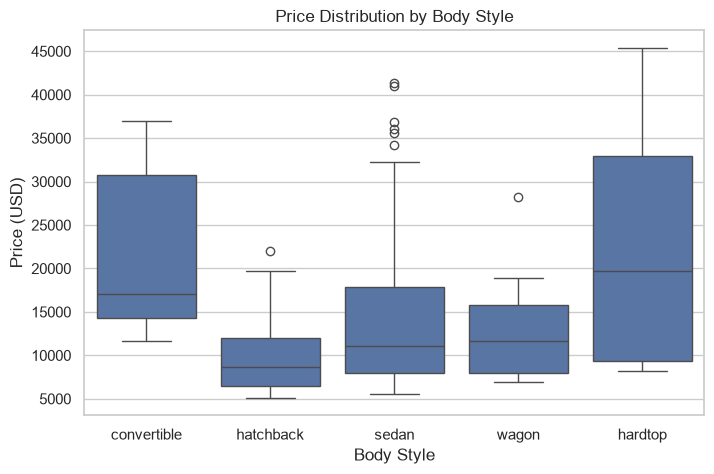

In [22]:
# TODO M2.3: boxplot price theo body_style
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_clean, x="body_style",y="price"
)

plt.title("Price Distribution by Body Style")
plt.xlabel("Body Style")
plt.ylabel("Price (USD)")

plt.show()

**Nhận xét:** <!-- 1--2 câu -->

Tất cả các body-style đều lệch phải theo categories. Trong đó sedan lệch phải xuất hiện nhiều outliers nhất

Sự phân tán của price theo body-style là rất nhỏ đối với dòng hatchback, sedan và wagon, trong đó hatchback có mức giá trung vị thấp nhất, còn wagon có phân phối chuẩn nhất trong số 4 dòng còn lại 

## M2.4 Engine size liên quan thế nào tới price?

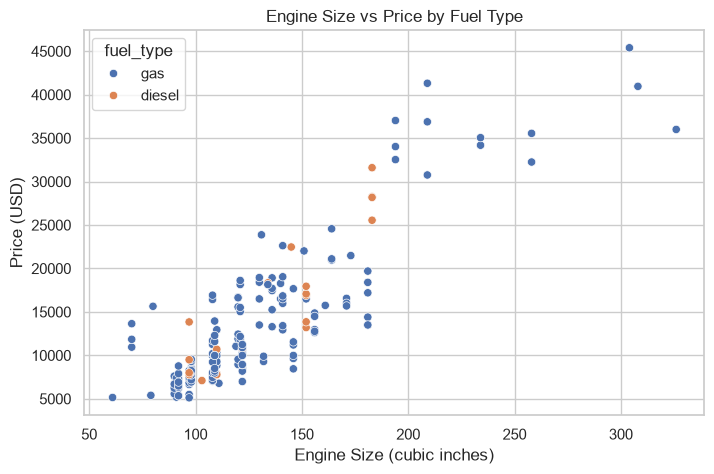

In [23]:
# TODO M2.4: scatterplot engine_size và price, hue=fuel_type
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df_clean, x="engine_size",y="price", hue = "fuel_type"
)

plt.title("Engine Size vs Price by Fuel Type")
plt.xlabel("Engine Size (cubic inches)")
plt.ylabel("Price (USD)")

plt.show()

**Nhận xét:** <!-- 1--2 câu -->

Engine Size và Price có tương quan tuyến tính dương khá mạnh : khi engine size tăng thì price tăng

## M2.5 Các feature numeric tương quan ra sao?

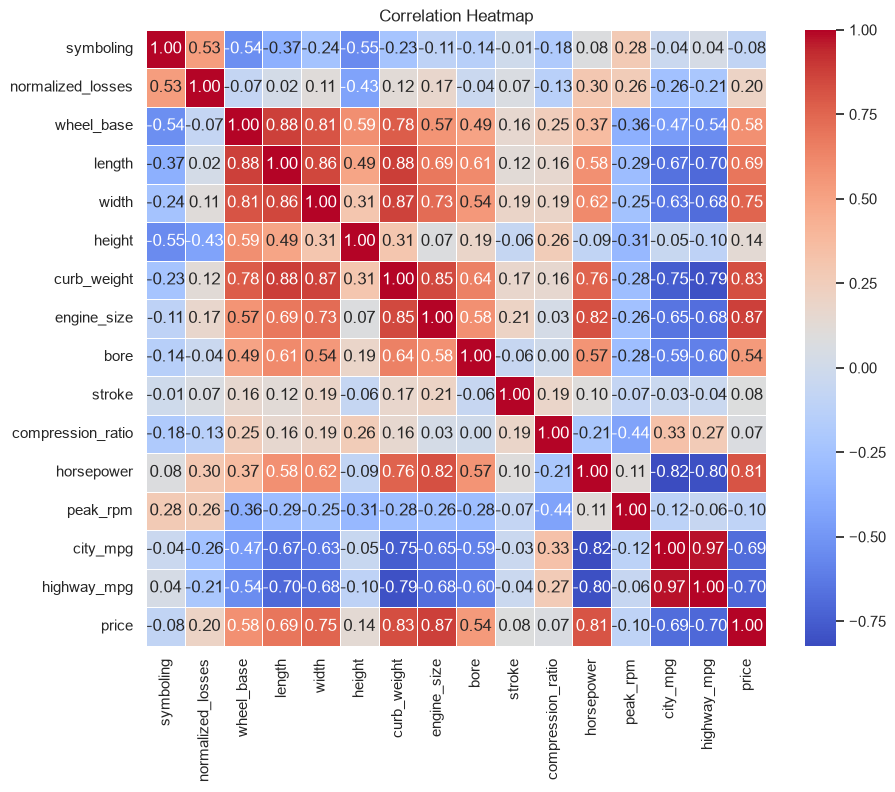

In [24]:
# TODO M2.5: correlation heatmap
plt.figure(figsize=(10, 8))

corr = df_clean.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

**Nhận xét:** <!-- 1--2 câu -->

price tương quan dương mạnh với horsepower, city_mpg, engine_size; highway_mpg tương quan dương mạnh với city_mpg; horse_power tương quan dương mạnh với engine_size

Dễ hiểu để kết luận rằng, khi giá tiền cao của xe sẽ kéo theo những lợi ích đối với xe đó : có thêm horsepower, city_mpg, engine_size, highway_mpg. Vì vậy xe giá cao thì có thể chắn chắn hiệu suất và lợi ích sẽ nhiều hơn so với các xe còn lại. 

## M2.6 Biểu đồ tự chọn

Đặt một câu hỏi mới, chọn chart phù hợp và không lặp nguyên năm biểu đồ trên.

## SỰ LIÊN HỆ GIỮA ĐỘ TIẾT KIỆM NHIÊN LIỆU GIỮA ENGINE SIZE VÀ CURB_WEIGHT?

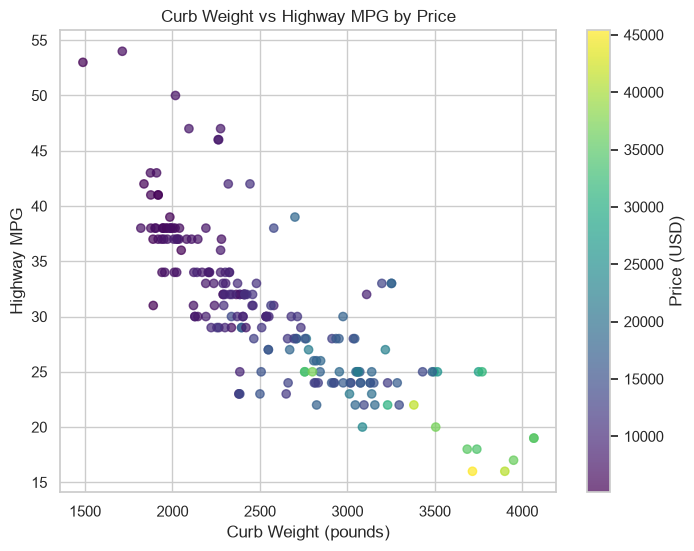

In [25]:
# TODO M2.6: biểu đồ tự chọn - scatter
plt.figure(figsize=(8,6))

plt.scatter(
    df_clean["curb_weight"],
    df_clean["highway_mpg"],
    c=df_clean["price"],  # Đổi thành màu sắc đại diện cho giá xe
    cmap="viridis",
    alpha=0.7
)

plt.colorbar(label="Price (USD)")
plt.xlabel("Curb Weight (pounds)")
plt.ylabel("Highway MPG")
plt.title("Curb Weight vs Highway MPG by Price")
plt.show()

**Nhận xét:** <!-- 1--2 câu -->

Nhìn chung highway_mpg và curb weight đang tương quan âm mạnh đối với price 

Curb_weight và price càng nhỏ thì lại giúp cho mức độ tiết kiệm nhiên liệu trên cao tốc (highway_mpg) tốt hơn so với những chiếc xe lớn hơn và đắt tiền hơn.

# Tổng hợp

Viết:

- 3--5 phát hiện chính có dẫn chứng;
- ít nhất 2 hạn chế của dataset;
- một ví dụ về correlation không đồng nghĩa causation;
- một câu hỏi nên phân tích tiếp.

## Tổng hợp của sinh viên

<!-- Viết khoảng 150--250 từ. -->

Các phát hiện chính: 
- Các giá trị price phân phối lệch trái nhiều(M2.1), các dòng xe phân khúc thấp phân bố nhiều hơn các dòng xe phân khúc cao
- Các dòng xe này đa số là sedan và hatchback(M2.2), ít là hardtop (M2.2). Thế nhưng những dòng xe ít người sử dụng này lại có sự phân bố hẹp, chứng tỏ dòng xe có body-type này (hatchback, wagon) có ít các phân khúc giá. Trong khi đó, dòng sedan nhiều người sử dụng và có nhiều phân khúc giá (M2.3)
- Engine_size và price có tính tương quan dương khá mạnh, chứng tỏ khi giá tiền cao thì động cơ lớn (M2.4)
- Sự liên hệ khi giá tiền cao của xe sẽ kéo theo những lợi ích đối với xe đó : có thêm horsepower mạnh, engine_size lớn ,city_mpg tốt hơn , highway_mpg tốt hơn. Vì vậy xe giá cao thì có thể chắc chắn hiệu suất và lợi ích sẽ nhiều hơn so với các xe còn lại (M2.5)


Hạn chế của dataset là :
- Missing value trong dataset khá nhiều, và khi sai cũng là để sai format "?"
- Có xuất hiện nhiều giá trị đa cộng tuyến ( như highway_mpg và city_mpg là tương quan dương gần như hoàn hảo, hoặc engine_size và price là tương quan dương xấp xỉ hoàn hảo (0.87)). Điều này khiến cho dữ liệu khó train và cần phải clean data


Một ví dụ về correlation không đồng nghĩa causation:
- curb_weight tỉ lệ nghịch với highway_mpg, nhưng không có nghĩa là curb_weight lớn thì highway_mpg nhỏ lại. Nó phụ thuộc phần nhiều thực tế là do engine_size, khi engine_size lớn thì highway_mpg sẽ nhỏ.

Một câu hỏi nên phân tích tiếp: So sánh correlation giữa curb_weight, engine_size so với highway_mpg để xem giả chứng thực tế, engine_size và highway_mpg, và curb_weight với highway_mpg